In [2]:
from xgboost import XGBRegressor
import os
import glob
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [3]:
df_all = pd.read_csv("all_data.csv")
df_all

,bbox_x1,bbox_y1,bbox_x2,bbox_y2,conf,class,median_m,angular_z,imu_gyro_z,imu_acc_x,...,ratio_diff,log_bbox_width,log_bbox_height,log_bbox_area,log_ratio_w,log_ratio_h,log_ratio_mean,log_ratio_area,log_ratio_diag,source_file
0,406.343628,319.237488,422.137848,343.154999,0.750268,0,1.0610,0.000186,0.000000,-0.008978,...,0.363065,2.759644,3.174611,5.934255,-2.664320,-1.866272,-2.187712,-4.530519,-2.004881,preprocessed_SoldierFront100-110.csv
1,338.622772,320.997101,353.408875,344.326141,0.736244,0,1.0620,0.000186,0.000000,-0.008978,...,0.336509,2.693688,3.149699,5.843387,-2.598364,-1.841360,-2.149878,-4.439659,-1.967858,preprocessed_SoldierFront100-110.csv
2,406.425507,319.276794,422.063110,343.386627,0.748280,0,1.0610,0.000186,0.000000,0.043096,...,0.351301,2.749679,3.182620,5.932298,-2.654354,-1.874280,-2.190107,-4.528563,-2.007500,preprocessed_SoldierFront100-110.csv
3,338.809448,321.090179,353.351593,344.466187,0.730411,0,1.0610,0.000186,0.000000,0.043096,...,0.324800,2.677051,3.151710,5.828761,-2.581728,-1.843371,-2.145897,-4.425035,-1.964596,preprocessed_SoldierFront100-110.csv
4,406.428711,319.309479,422.181030,343.338165,0.748989,0,1.0610,0.000186,0.000000,0.043096,...,0.358266,2.756988,3.179248,5.936236,-2.661663,-1.870909,-2.190080,-4.532500,-2.007315,preprocessed_SoldierFront100-110.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,337.111603,316.819244,400.950653,345.951233,0.755896,1,1.0260,0.200513,0.177721,-0.122703,...,0.585312,4.156365,3.371837,7.528202,-2.488646,-2.177906,-2.321254,-4.666466,-2.419413,preprocessed_TankSide95-105.csv
646,615.525635,313.758240,639.000000,367.489532,0.528726,1,0.9575,0.200513,0.191556,-0.117316,...,1.169176,3.155909,3.983996,7.139905,-1.488198,-2.790057,-1.940734,-4.278203,-2.239803,preprocessed_TankSide95-105.csv
647,595.601685,313.960632,639.000000,364.689484,0.475336,1,0.9870,0.200513,0.191556,-0.117316,...,0.750565,3.770421,3.926495,7.696915,-2.102706,-2.732557,-2.368841,-4.835160,-2.369561,preprocessed_TankSide95-105.csv
648,588.698120,315.298706,639.000000,343.233093,0.722314,1,1.0280,-0.273218,0.208583,-0.129885,...,0.194655,3.918042,3.329858,7.247901,-2.250326,-2.135928,-2.191492,-4.386191,-2.220910,preprocessed_TankSide95-105.csv


In [4]:
from sklearn.ensemble import RandomForestRegressor

def rf_model(seed):
    return RandomForestRegressor(
        n_estimators=100,
        random_state=seed,
        n_jobs=-1
    )

def xg_model(seed):
    return XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=seed,
    n_jobs=-1
)


def evaluate_with_seeds(model_fn, X, y, seeds=range(10), test_size=0.2):
    maes, rmses, r2s = [], [], []

    for seed in seeds:
        # split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=seed
        )

        # 모델 생성 (seed마다 새로)
        model = model_fn(seed)

        # 학습
        model.fit(X_train, y_train)

        # 예측
        y_pred = model.predict(X_test)

        # metric 계산
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)

    # 평균 + 표준편차
    print("\n[RESULT]")
    print(f"MAE : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
    print(f"RMSE: {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
    print(f"R2  : {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")

    return


[RESULT]
MAE : 0.0386
RMSE: 0.0701
R2  : 0.9342


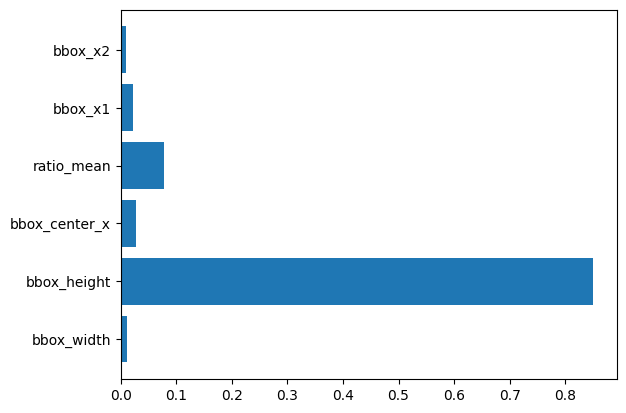


[RESULT]
MAE : 0.0379 ± 0.0034
RMSE: 0.0651 ± 0.0090
R2  : 0.9397 ± 0.0187

[RESULT]
MAE : 0.0391 ± 0.0034
RMSE: 0.0664 ± 0.0082
R2  : 0.9376 ± 0.0172


In [5]:
# target 변수 제외
# 데이터 전처리

feature_cols = [
    "bbox_width",
    "bbox_height",
    "bbox_center_x",
    "ratio_mean",  
    "bbox_x1",
    "bbox_x2",
]

X = df_all[feature_cols].copy()
y = df_all["median_m"].copy()


X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=43
)


X_train = pd.DataFrame(
    X_train,
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    X_test,
    columns=X_test.columns,
    index=X_test.index
)

rf = RandomForestRegressor(
        n_estimators=100,
        random_state=46,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n[RESULT]")
print(f"MAE : {np.mean(mae):.4f}")
print(f"RMSE: {np.mean(rmse):.4f}")
print(f"R2  : {np.mean(r2):.4f}")


importances = rf.feature_importances_
plt.barh(X_train.columns, importances)
plt.show()
evaluate_with_seeds(rf_model, X, y)
evaluate_with_seeds(xg_model, X, y)

In [5]:
def rf_model(seed):
    return RandomForestRegressor(
        n_estimators=100,
        random_state=seed,
        n_jobs=-1
    )

In [12]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=47
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=47)

# 모델
xg = XGBRegressor(random_state=48, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100],
    "max_depth": [10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
}
# Grid Search
grid_search = GridSearchCV(
    estimator=xg,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

summary

Fitting 5 folds for each of 5 candidates, totalling 25 fits


Best Params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100}
Best CV Score (MAE): 0.04181216490956453
Test MAE: 0.03369109974457667
Test RMSE: 0.06684385477724529
Test R2: 0.9416473035146393


,learning_rate,max_depth,n_estimators,mean_test_score,std_test_score,rank_test_score
3,0.10,10,100,-0.041812,0.002670,1
4,0.20,10,100,-0.042263,0.001586,2
2,0.05,10,100,-0.042295,0.002356,3
1,0.03,10,100,-0.046560,0.001503,4
0,0.01,10,100,-0.102864,0.007211,5


In [ ]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=45
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=45)

# 모델
xg = XGBRegressor(random_state=48, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100,200, 300 400],
    "max_depth": [10],
    "learning_rate": [ 0.1],        
    "subsample": [1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}
# Grid Search
grid_search = GridSearchCV(
    estimator=xg,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

summary

Fitting 5 folds for each of 3 candidates, totalling 15 fits


Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'subsample': 1.0}
Best CV Score (MAE): 0.038102932595289664
Test MAE: 0.04399452892633584
Test RMSE: 0.07783504755632024
Test R2: 0.913474181685125


,colsample_bytree,learning_rate,max_depth,n_estimators,subsample,mean_test_score,std_test_score,rank_test_score
2,1.0,0.1,10,100,1.0,-0.038103,0.007333,1
1,0.8,0.1,10,100,1.0,-0.041439,0.005790,2
0,0.6,0.1,10,100,1.0,-0.049306,0.004402,3


In [20]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=44
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=44)

# 모델
xg = XGBRegressor(random_state=48, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100],
    "max_depth": [10],
    "learning_rate": [0.1],
    "subsample": [1.0],
    "colsample_bytree": [1.0],
    "min_child_weight": [1, 3, 5, 7]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=xg,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

summary

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV Score (MAE): 0.04008536993311001
Test MAE: 0.030426041392179626
Test RMSE: 0.058431839813302654
Test R2: 0.9577695583257491


,colsample_bytree,learning_rate,max_depth,min_child_weight,n_estimators,subsample,mean_test_score,std_test_score,rank_test_score
1,1.0,0.1,10,3,100,1.0,-0.040085,0.003839,1
3,1.0,0.1,10,7,100,1.0,-0.040191,0.005203,2
2,1.0,0.1,10,5,100,1.0,-0.040708,0.004486,3
0,1.0,0.1,10,1,100,1.0,-0.042389,0.004968,4


In [29]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=44
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=3)

# 모델
xg = XGBRegressor(random_state=48, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100],
    "max_depth": [10],
    "learning_rate": [0.1],
    "subsample": [1.0],
    "colsample_bytree": [1.0],
    "min_child_weight": [3],
    "gamma": [0],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [3, 5, 10]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=xg,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

summary

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Params: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 10, 'subsample': 1.0}
Best CV Score (MAE): 0.038326807079406874
Test MAE: 0.033883057786868155
Test RMSE: 0.06383672389076021
Test R2: 0.9495956888946983


,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,subsample,mean_test_score,std_test_score,rank_test_score
2,1.0,0,0.1,10,3,100,0.00,10,1.0,-0.038327,0.003571,1
5,1.0,0,0.1,10,3,100,0.01,10,1.0,-0.038542,0.003420,2
4,1.0,0,0.1,10,3,100,0.01,5,1.0,-0.038628,0.004064,3
7,1.0,0,0.1,10,3,100,0.10,5,1.0,-0.039004,0.003969,4
6,1.0,0,0.1,10,3,100,0.10,3,1.0,-0.039308,0.004416,5
8,1.0,0,0.1,10,3,100,0.10,10,1.0,-0.039330,0.003620,6
1,1.0,0,0.1,10,3,100,0.00,5,1.0,-0.039398,0.004241,7
0,1.0,0,0.1,10,3,100,0.00,3,1.0,-0.039713,0.003582,8
3,1.0,0,0.1,10,3,100,0.01,3,1.0,-0.039912,0.003191,9


In [35]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=22
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=22)

# 모델
xg = XGBRegressor(random_state=48, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100],
    "max_depth": [10],
    "learning_rate": [0.1],
    "subsample": [1.0],
    "colsample_bytree": [1.0],
    "min_child_weight": [3],
    "gamma": [0],
    "reg_alpha": [0, 0.01],
    "reg_lambda": [1, 3]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=xg,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

summary

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': 0.01, 'reg_lambda': 3, 'subsample': 1.0}
Best CV Score (MAE): 0.039753501839362645
Test MAE: 0.03120456654291887
Test RMSE: 0.05517595147808399
Test R2: 0.9558107223636463


,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,subsample,mean_test_score,std_test_score,rank_test_score
3,1.0,0,0.1,10,3,100,0.01,3,1.0,-0.039754,0.005020,1
1,1.0,0,0.1,10,3,100,0.00,3,1.0,-0.040006,0.005094,2
2,1.0,0,0.1,10,3,100,0.01,1,1.0,-0.040136,0.004744,3
0,1.0,0,0.1,10,3,100,0.00,1,1.0,-0.040185,0.004901,4


In [38]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=22)

# 모델
xg = XGBRegressor(random_state=48, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100],
    "max_depth": [10],
    "learning_rate": [0.1],
    "subsample": [1.0],
    "colsample_bytree": [1.0],
    "min_child_weight": [3],
    "gamma": [0],
    "reg_alpha": [0, 0.01],
    "reg_lambda": [1]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=xg,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

summary

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Params: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': 0.01, 'reg_lambda': 1, 'subsample': 1.0}
Best CV Score (MAE): 0.04301203862978861
Test MAE: 0.031679645043153015
Test RMSE: 0.05571227328347735
Test R2: 0.9588470089202901


,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,subsample,mean_test_score,std_test_score,rank_test_score
1,1.0,0,0.1,10,3,100,0.01,1,1.0,-0.043012,0.001716,1
0,1.0,0,0.1,10,3,100,0.00,1,1.0,-0.043774,0.002295,2


In [42]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=52
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=22)

# 모델
xg = XGBRegressor(random_state=48, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100],
    "max_depth": [10],
    "learning_rate": [0.1],
    "subsample": [1.0],
    "colsample_bytree": [1.0],
    "min_child_weight": [3],
    "gamma": [0],
    "reg_alpha": [0, 0.01],
    "reg_lambda": [1],
    "colsample_bynode": [ 1.0]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=xg,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

summary

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Params: {'colsample_bynode': 1.0, 'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1.0}
Best CV Score (MAE): 0.04003560886933253
Test MAE: 0.03225963830947875
Test RMSE: 0.05757345068057704
Test R2: 0.9546653764372444


,colsample_bynode,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,subsample,mean_test_score,std_test_score,rank_test_score
0,1.0,1.0,0,0.1,10,3,100,0.00,1,1.0,-0.040036,0.007957,1
1,1.0,1.0,0,0.1,10,3,100,0.01,1,1.0,-0.040270,0.007038,2


In [ ]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 준비되어 있다고 가정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=52
)

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=22)

# 모델
xg = XGBRegressor(random_state=48, n_jobs=-1)

# 하이퍼파라미터 후보
param_grid = {
    "n_estimators": [100],
    "max_depth": [10],
    "learning_rate": [0.1],
    "subsample": [1.0],
    "colsample_bytree": [1.0],
    "min_child_weight": [3],
    "gamma": [0],
    "reg_alpha": [0],
    "reg_lambda": [1],
    "colsample_bynode": [1.0]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=xg,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",   # 회귀면 보통 MAE나 RMSE 계열 많이 씀
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 최적 파라미터
print("Best Params:", grid_search.best_params_)
print("Best CV Score (MAE):", -grid_search.best_score_)

# 최적 모델
best_model = grid_search.best_estimator_

# 최종 test 평가
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

results = pd.DataFrame(grid_search.cv_results_)

# params 딕셔너리를 열로 펼치기
params_df = pd.json_normalize(results["params"])

# 필요한 점수 컬럼만 붙이기
summary = pd.concat(
    [
        params_df,
        results[["mean_test_score", "std_test_score", "rank_test_score"]]
    ],
    axis=1
)

# 순위대로 정렬
summary = summary.sort_values("rank_test_score")

summary

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Params: {'colsample_bynode': 1.0, 'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1.0}
Best CV Score (MAE): 0.04003560886933253
Test MAE: 0.03225963830947875
Test RMSE: 0.05757345068057704
Test R2: 0.9546653764372444


,colsample_bynode,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,subsample,mean_test_score,std_test_score,rank_test_score
0,1.0,1.0,0,0.1,10,3,100,0.00,1,1.0,-0.040036,0.007957,1
1,1.0,1.0,0,0.1,10,3,100,0.01,1,1.0,-0.040270,0.007038,2


In [45]:
import time
import pickle
import os
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------
# 0. 최종 확정 하이퍼파라미터
# ---------------------------
final_params = {
    "n_estimators": 100,
    "max_depth": 10,
    "learning_rate": 0.1,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "min_child_weight": 3,
    "gamma": 0,
    "reg_alpha": 0.01,   # best 값으로 바꿔
    "reg_lambda": 1,
    "colsample_bynode": 1.0,
    "random_state": 48,
    "n_jobs": -1,
    "objective": "reg:squarederror"
}

# ---------------------------
# 1. train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=52
)

# ---------------------------
# 2. 최종 모델 학습
# ---------------------------
model = XGBRegressor(**final_params)

train_start = time.perf_counter()
model.fit(X_train, y_train)
train_end = time.perf_counter()

train_time = train_end - train_start

# ---------------------------
# 3. test 성능 평가
# ---------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Final Test Performance ===")
print(f"Test MAE : {mae:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test R2  : {r2:.6f}")
print(f"Train Time (s): {train_time:.6f}")

# ---------------------------
# 4. CV 안정성 점검
# ---------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=22)

cv_mae_scores = -cross_val_score(
    XGBRegressor(**final_params),
    X, y,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

cv_rmse_scores = np.sqrt(
    -cross_val_score(
        XGBRegressor(**final_params),
        X, y,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
)

cv_r2_scores = cross_val_score(
    XGBRegressor(**final_params),
    X, y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("\n=== 5-Fold CV Stability ===")
print("MAE per fold :", cv_mae_scores)
print(f"MAE mean±std : {cv_mae_scores.mean():.6f} ± {cv_mae_scores.std():.6f}")

print("RMSE per fold:", cv_rmse_scores)
print(f"RMSE mean±std: {cv_rmse_scores.mean():.6f} ± {cv_rmse_scores.std():.6f}")

print("R2 per fold  :", cv_r2_scores)
print(f"R2 mean±std  : {cv_r2_scores.mean():.6f} ± {cv_r2_scores.std():.6f}")

# ---------------------------
# 5. random_state 바꿔서 안정성 점검
# ---------------------------
split_seeds = [0, 11, 22, 33, 44, 55, 66, 77, 88, 99]
stability_results = []

for seed in split_seeds:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    model_s = XGBRegressor(**final_params)
    model_s.fit(X_train_s, y_train_s)
    pred_s = model_s.predict(X_test_s)

    mae_s = mean_absolute_error(y_test_s, pred_s)
    rmse_s = np.sqrt(mean_squared_error(y_test_s, pred_s))
    r2_s = r2_score(y_test_s, pred_s)

    stability_results.append({
        "split_seed": seed,
        "MAE": mae_s,
        "RMSE": rmse_s,
        "R2": r2_s
    })

stability_df = pd.DataFrame(stability_results)

print("\n=== Split Stability Check ===")
print(stability_df)
print("\nMean ± Std")
print(f"MAE : {stability_df['MAE'].mean():.6f} ± {stability_df['MAE'].std():.6f}")
print(f"RMSE: {stability_df['RMSE'].mean():.6f} ± {stability_df['RMSE'].std():.6f}")
print(f"R2  : {stability_df['R2'].mean():.6f} ± {stability_df['R2'].std():.6f}")

# ---------------------------
# 6. 추론 속도 측정
# ---------------------------
# 전체 test 예측 시간
start = time.perf_counter()
_ = model.predict(X_test)
end = time.perf_counter()

total_infer_time = end - start
per_sample_infer_time = total_infer_time / len(X_test)

print("\n=== Inference Speed ===")
print(f"Total inference time on X_test: {total_infer_time:.8f} sec")
print(f"Per-sample inference time     : {per_sample_infer_time:.8f} sec")

# ---------------------------
# 7. 한 샘플 추론 반복 측정
# ---------------------------
x_one = X_test.iloc[[0]]

repeat = 1000
start = time.perf_counter()
for _ in range(repeat):
    _ = model.predict(x_one)
end = time.perf_counter()

single_sample_avg = (end - start) / repeat

print(f"Single-sample avg inference ({repeat} runs): {single_sample_avg:.8f} sec")

# ---------------------------
# 8. 모델 저장 후 파일 크기 확인
# ---------------------------
model_path = "xgb_final_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model, f)

file_size_mb = os.path.getsize(model_path) / (1024 * 1024)

print("\n=== Model File Size ===")
print(f"Saved model path: {model_path}")
print(f"Model size      : {file_size_mb:.4f} MB")

=== Final Test Performance ===
Test MAE : 0.032936
Test RMSE: 0.058568
Test R2  : 0.953086
Train Time (s): 3.479905

=== 5-Fold CV Stability ===
MAE per fold : [0.03184757 0.04357898 0.03526293 0.0361891  0.03657377]
MAE mean±std : 0.036690 ± 0.003826
RMSE per fold: [0.05712281 0.07774786 0.06623462 0.0774762  0.06440506]
RMSE mean±std: 0.068597 ± 0.007967
R2 per fold  : [0.95263731 0.91987144 0.94234972 0.91298699 0.94236598]
R2 mean±std  : 0.934042 ± 0.015021

=== Split Stability Check ===
   split_seed       MAE      RMSE        R2
0           0  0.034753  0.057877  0.954578
1          11  0.042799  0.077023  0.923995
2          22  0.031848  0.057123  0.952637
3          33  0.036889  0.060352  0.952321
4          44  0.030628  0.056778  0.960127
5          55  0.034961  0.061351  0.946125
6          66  0.042717  0.075708  0.923744
7          77  0.038239  0.072515  0.927944
8          88  0.033925  0.058022  0.951854
9          99  0.033853  0.060615  0.948784

Mean ± Std
MAE : 0

In [46]:
import time
import numpy as np
from xgboost import XGBRegressor

# ---------------------------
# 1. 최종 모델: 전체 데이터(X, y)로 학습
# ---------------------------
final_model = XGBRegressor(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    min_child_weight=3,
    gamma=0,
    reg_alpha=0.01,   # 최종 선택값으로 바꿔
    reg_lambda=1,
    colsample_bynode=1.0,
    random_state=48,
    n_jobs=-1,
    objective="reg:squarederror"
)

final_model.fit(X, y)

# ---------------------------
# 2. 전체 X 추론 시간
# ---------------------------
start = time.perf_counter()
pred_all = final_model.predict(X)
end = time.perf_counter()

total_time = end - start
per_sample_time = total_time / len(X)

print("=== Inference Speed on Full X ===")
print(f"Total inference time : {total_time:.8f} sec")
print(f"Per-sample avg time  : {per_sample_time:.8f} sec")

# ---------------------------
# 3. 단일 샘플 추론 시간
# ---------------------------
x_one = X.iloc[[0]]

# 워밍업
_ = final_model.predict(x_one)

repeat = 1000
start = time.perf_counter()
for _ in range(repeat):
    _ = final_model.predict(x_one)
end = time.perf_counter()

single_sample_avg = (end - start) / repeat

print("\n=== Single Sample Inference ===")
print(f"Single-sample avg time ({repeat} runs): {single_sample_avg:.8f} sec")

=== Inference Speed on Full X ===
Total inference time : 0.00583797 sec
Per-sample avg time  : 0.00000898 sec

=== Single Sample Inference ===
Single-sample avg time (1000 runs): 0.01708321 sec


In [47]:
import pickle

# feature_cols 예시
feature_cols = list(X.columns)

# final_model, feature_cols 저장
with open("xgb_final_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("xgb_feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("저장 완료")
print("- xgb_final_model.pkl")
print("- xgb_feature_cols.pkl")

저장 완료
- xgb_final_model.pkl
- xgb_feature_cols.pkl
